## NumPy, Pandas & Matplotlib Integration

In [2]:
!unzip /content/drive/MyDrive/BootGenAI/globalpowerplantdatabasev130.zip

Archive:  /content/drive/MyDrive/BootGenAI/globalpowerplantdatabasev130.zip
  inflating: A_Global_Database_of_Power_Plants.pdf  
  inflating: Estimating_Power_Plant_Generation_in_the_Global_Power_Plant_Database.pdf  
  inflating: global_power_plant_database.csv  
  inflating: README.txt              
  inflating: RELEASE_NOTES.txt       


In [3]:
import pandas as pd

df = pd.read_csv('/content/global_power_plant_database.csv')
df.head()


/tmp/ipython-input-1648323721.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [4]:
df.shape

(34936, 36)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [6]:
print(df.isna().sum())

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [7]:
# Drop sparse columns
df = df.drop(columns=['other_fuel2', 'other_fuel3'])

# Fill categorical with 'Unknown'
df['owner'] = df['owner'].fillna('Unknown')

# Fill commissioning_year with median
df['commissioning_year'] = df['commissioning_year'].fillna(df['commissioning_year'].median())

# Fill generation columns with 0
gen_cols = [col for col in df.columns if 'generation_gwh' in col]
df[gen_cols] = df[gen_cols].fillna(0)

# Drop rows missing critical info
df = df.dropna(subset=['url', 'source'])

In [8]:
# Exploratory Data Analysis
print(df.describe())

        capacity_mw      latitude     longitude  commissioning_year  \
count  34918.000000  34918.000000  34918.000000        34918.000000   
mean     163.234514     32.805820     -6.976780         2002.210448   
std      489.649892     22.639383     78.425671           17.219154   
min        1.000000    -77.847000   -179.977700         1896.000000   
25%        4.900000     29.250525    -77.654250         2007.000000   
50%       16.700000     39.719950     -2.134500         2007.000000   
75%       75.000000     46.244950     49.594850         2007.000000   
max    22500.000000     71.292000    179.388700         2020.000000   

       year_of_capacity_data  generation_gwh_2013  generation_gwh_2014  \
count           14887.000000         34918.000000         34918.000000   
mean             2018.218849           108.921786           135.932713   
std                 1.606428           960.111707          1049.358952   
min              2000.000000          -947.600000          -989.

In [11]:
# Distribution par pays
print(df['country'].value_counts().head(5))
print()
# Distribution par type de fuel
print(df['primary_fuel'].value_counts())


country
USA    9833
CHN    4235
GBR    2735
BRA    2360
FRA    2155
Name: count, dtype: int64

primary_fuel
Solar             10665
Hydro              7155
Wind               5338
Gas                3988
Coal               2329
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


In [12]:
#Statistical Analysis
import numpy as np

# On prend juste deux colonnes : fuel et production
fuel_power = df[['primary_fuel', 'generation_gwh_2019']].dropna()

# On calcule les stats fuel par fuel
for fuel, group in fuel_power.groupby('primary_fuel'):
    values = group['generation_gwh_2019'].to_numpy()  # convertir en array NumPy

    print(f"{fuel}: mean={np.mean(values):.2f}, median={np.median(values):.2f}, std={np.std(values):.2f}")


Biomass: mean=17.98, median=0.00, std=86.14
Coal: mean=402.66, median=0.00, std=1670.10
Cogeneration: mean=94.83, median=48.87, std=116.71
Gas: mean=396.24, median=0.00, std=1346.10
Geothermal: mean=82.25, median=0.00, std=334.41
Hydro: mean=39.44, median=0.00, std=395.73
Nuclear: mean=4139.21, median=0.00, std=7162.28
Oil: mean=9.74, median=0.00, std=232.89
Other: mean=32.13, median=0.00, std=84.36
Petcoke: mean=580.63, median=151.40, std=1352.11
Solar: mean=6.72, median=0.00, std=39.71
Storage: mean=-0.24, median=-0.00, std=3.97
Waste: mean=41.47, median=0.00, std=95.84
Wave and Tidal: mean=0.00, median=0.00, std=0.00
Wind: mean=55.33, median=0.00, std=175.59


In [15]:
#Group plants by year
df.groupby('commissioning_year')['name'].count()

,name
commissioning_year,
1896.000000,1
1899.000000,1
1900.000000,6
1901.000000,2
1902.000000,4
...,...
2019.000000,596
2019.000000,1
2019.411765,1


In [16]:
#Group by year AND fuel type
df.groupby(['commissioning_year', 'primary_fuel'])['name'].count()

commissioning_year  primary_fuel
1896.0              Hydro             1
1899.0              Hydro             1
1900.0              Gas               1
                    Hydro             3
                    Oil               2
                                   ... 
2020.0              Gas               6
                    Solar           122
                    Storage           2
                    Waste             2
                    Wind             17
Name: name, Length: 2668, dtype: int64

In [18]:
#Turn into NumPy arrays
values = df.groupby(['commissioning_year', 'primary_fuel'])['name'].count().to_numpy()

/tmp/ipython-input-639380707.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="primary_fuel", y="capacity_mw", data=df, estimator=np.mean, ci=None)


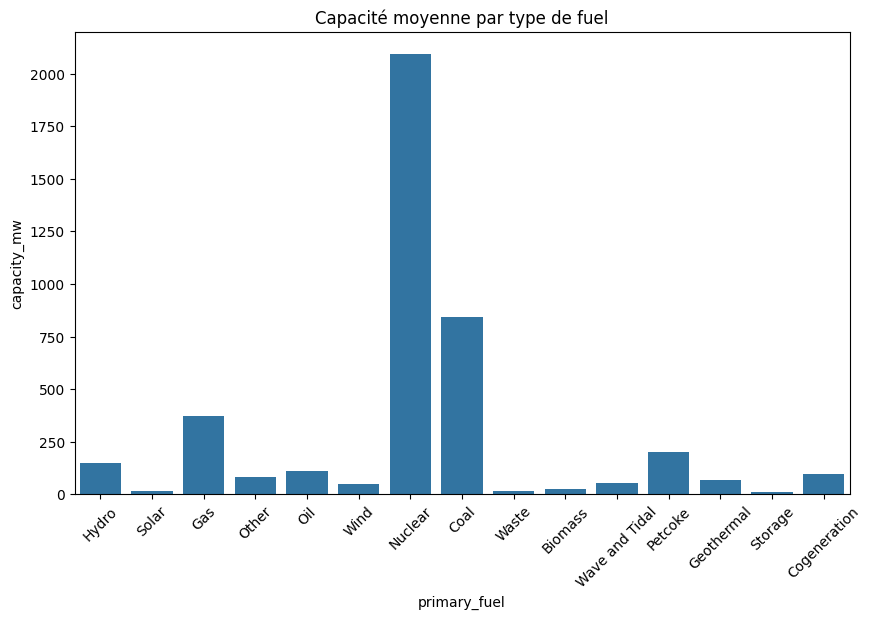

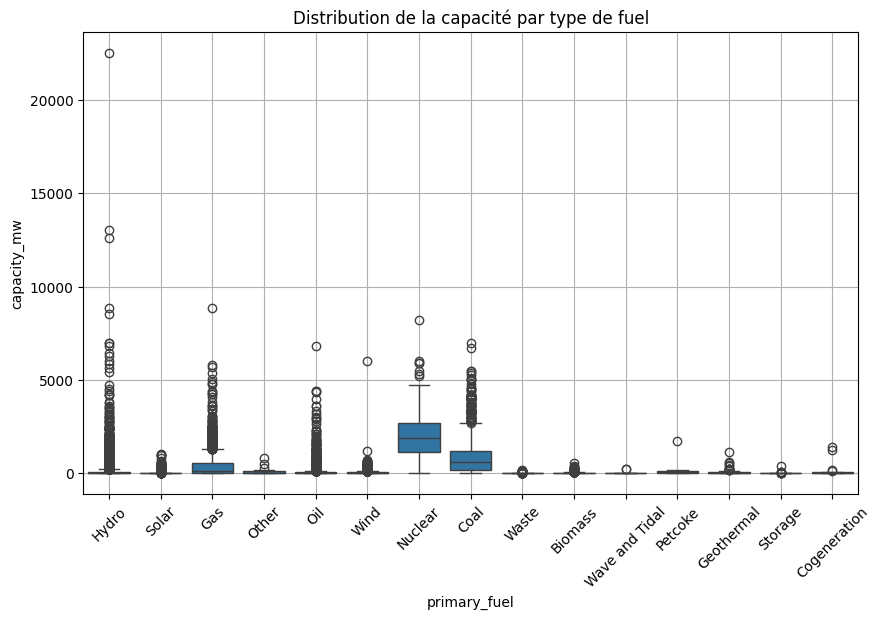

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Barplot : moyenne de la capacité par type de fuel
plt.figure(figsize=(10,6))
sns.barplot(x="primary_fuel", y="capacity_mw", data=df, estimator=np.mean, ci=None)
plt.title("Capacité moyenne par type de fuel")
plt.xticks(rotation=45)
plt.show()

# Boxplot : dispersion de la capacité par fuel
plt.figure(figsize=(10,6))
sns.boxplot(x="primary_fuel", y="capacity_mw", data=df)
plt.title("Distribution de la capacité par type de fuel")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [25]:
import numpy as np
import pandas as pd

# Encodage fuel en nombre (exemple simple)
fuel_map = {fuel: idx for idx, fuel in enumerate(df['primary_fuel'].unique())}
df['fuel_encoded'] = df['primary_fuel'].map(fuel_map)

# Construire une matrice avec 3 colonnes : fuel, capacity, latitude
matrix = df[['fuel_encoded', 'capacity_mw', 'latitude']].dropna().to_numpy()

print(matrix.shape)  # (n, 3)

(34918, 3)


In [26]:
# Transposer
matrix_T = matrix.T

# Produit matriciel
result = np.dot(matrix_T, matrix)  # matrice de corrélations approximatives

In [27]:
# Matrice de covariance
cov_matrix = np.cov(matrix_T)

# Décomposition en valeurs propres
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [2.39757248e+05 8.02923780e+00 5.12466501e+02]
Eigenvectors:
 [[ 7.59441778e-04  9.99982083e-01 -5.93770929e-03]
 [ 9.99999517e-01 -7.55727612e-04  6.27740360e-04]
 [-6.23241822e-04  5.93818315e-03  9.99982175e-01]]


In [28]:
#Complex Filtering
import numpy as np

# Example: select plants with capacity > mean capacity
mean_capacity = np.mean(df['capacity_mw'])
high_capacity = df[df['capacity_mw'] > mean_capacity]

print(high_capacity.head())

   country country_long         name   gppd_idnr  capacity_mw  latitude  \
10     ALB      Albania       Fierza  WRI1002170        500.0   42.2514   
11     ALB      Albania        Koman  WRI1002171        600.0   42.1033   
15     ALB      Albania  Vau i Dijes  WRI1002175        250.0   42.0137   
19     DZA      Algeria  Ain Djasser  WRI1023776        520.0   35.8665   
27     DZA      Algeria        Arbaa  WRI1023777        560.0   36.5988   

    longitude primary_fuel other_fuel1  commissioning_year  ...  \
10    20.0431        Hydro         NaN              1978.0  ...   
11    19.8224        Hydro         NaN              1985.0  ...   
15    19.6359        Hydro         NaN              1971.0  ...   
19     6.0262          Gas         Oil              2007.0  ...   
27     3.1375          Gas         Oil              2010.0  ...   

   estimated_generation_gwh_2014 estimated_generation_gwh_2015  \
10                       1276.61                       1503.72   
11            

In [29]:
#Multiple Conditions
mask = (df['capacity_mw'] > np.percentile(df['capacity_mw'], 90)) & (df['primary_fuel'] == 'Coal')
top_coal_plants = df[mask]

print(top_coal_plants[['name', 'capacity_mw']].head())


                                       name  capacity_mw
119  CENTRAL BAHIA BLANCA (PIEDRA BUENA) SA        620.0
141                               COSTANERA       1982.2
299                            PUERTO NUEVO        589.0
310                             SAN NICOLAS        644.0
355                               Bayswater       2640.0


In [30]:
# Normalize capacity values (min-max scaling)
df['capacity_norm'] = (df['capacity_mw'] - np.min(df['capacity_mw'])) / (np.max(df['capacity_mw']) - np.min(df['capacity_mw']))


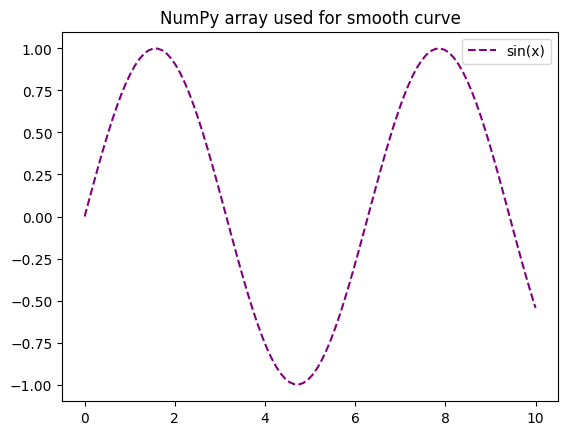

In [31]:
#Custom Line Styles
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)  # 100 points between 0 and 10
y = np.sin(x)

plt.plot(x, y, linestyle='--', color='purple', label='sin(x)')
plt.legend()
plt.title("NumPy array used for smooth curve")
plt.show()

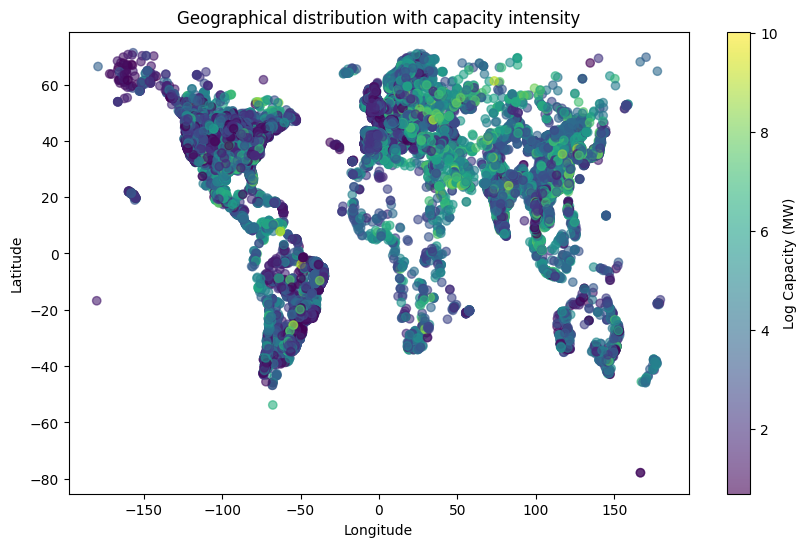

In [38]:
#Scatter with Color Encoding
capacity = df['capacity_mw'].to_numpy()
lat = df['latitude'].to_numpy()
lon = df['longitude'].to_numpy()

plt.figure(figsize=(10,6))
plt.scatter(lon, lat, c=np.log1p(capacity), cmap='viridis', alpha=0.6)
plt.colorbar(label="Log Capacity (MW)")
plt.title("Geographical distribution with capacity intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


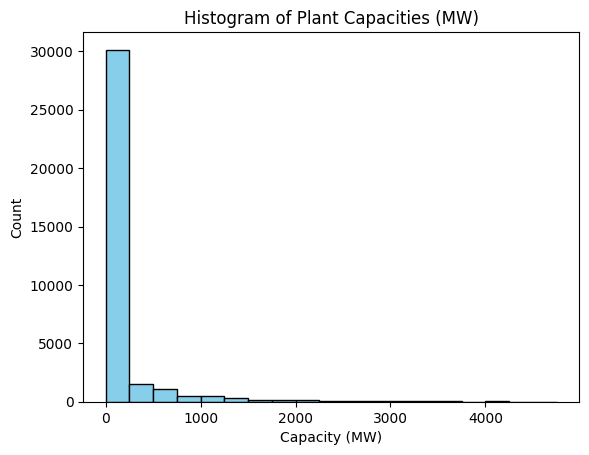

In [39]:
#Sophisticated Plots: Histograms with NumPy bins
values = df['capacity_mw'].to_numpy()

plt.hist(values, bins=np.arange(0, 5000, 250), color='skyblue', edgecolor='black')
plt.title("Histogram of Plant Capacities (MW)")
plt.xlabel("Capacity (MW)")
plt.ylabel("Count")
plt.show()
